In [6]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_data.csv to customer_churn_data.csv


In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Explainability
import shap

# Colour palette
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
sns.set_theme(style='whitegrid', font_scale=1.1)

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [7]:
df = pd.read_csv('/content/customer_churn_data.csv')

print('=== Dataset Overview ===')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('Column Data Types:')
print(df.dtypes)
print()
print('First 5 rows:')
df.head()

=== Dataset Overview ===
Shape: 1000 rows × 10 columns

Column Data Types:
CustomerID           int64
Age                  int64
Gender              object
Tenure               int64
MonthlyCharges     float64
ContractType        object
InternetService     object
TotalCharges       float64
TechSupport         object
Churn               object
dtype: object

First 5 rows:


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [8]:
print('=== Statistical Summary (Numerical Features) ===')
df.describe()

=== Statistical Summary (Numerical Features) ===


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [9]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print()
print('=== Target Variable Distribution ===')
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

=== Missing Values ===
                 Missing Count  Missing %
InternetService            297       29.7

=== Target Variable Distribution ===
       Count  Percentage
Churn                   
Yes      883        88.3
No       117        11.7


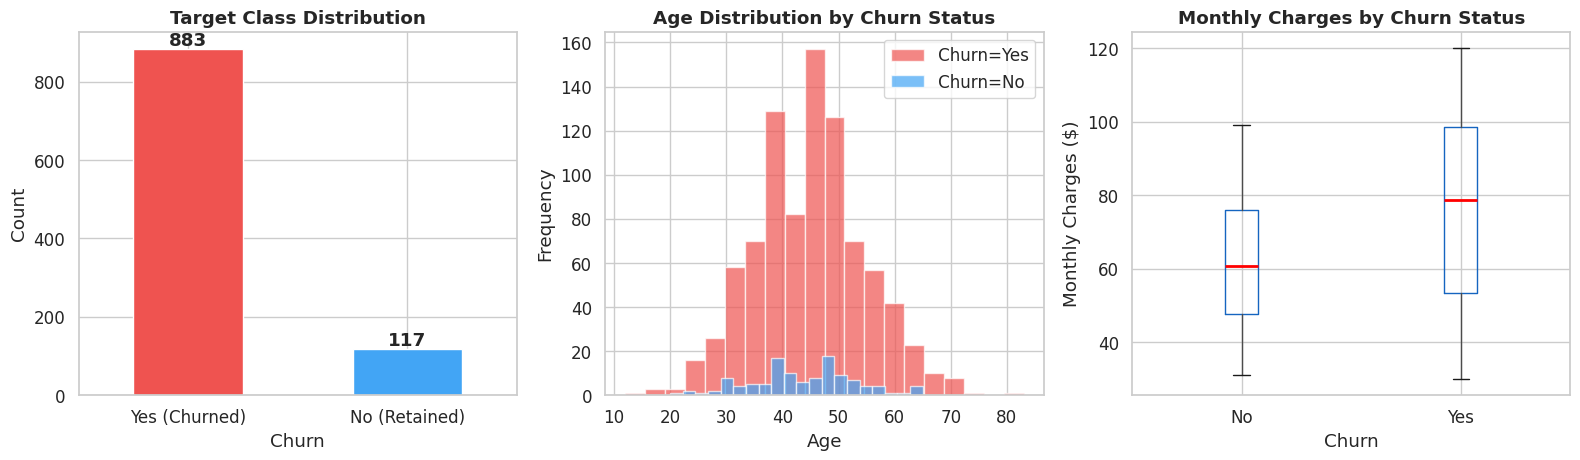

Figure saved: fig_eda_overview.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Class imbalance ---
churn_counts.plot.bar(ax=axes[0], color=['#EF5350', '#42A5F5'], edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Yes (Churned)', 'No (Retained)'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# --- Age distribution by Churn ---
for label, colour in zip(['Yes', 'No'], ['#EF5350', '#42A5F5']):
    axes[1].hist(df[df['Churn'] == label]['Age'], bins=20, alpha=0.7, color=colour, label=f'Churn={label}')
axes[1].set_title('Age Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# --- Monthly Charges by Churn ---
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2],
           boxprops=dict(color='#1565C0'), medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Monthly Charges ($)')
fig.suptitle('')  # remove auto-generated title

plt.tight_layout()
plt.savefig('fig_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_eda_overview.png')

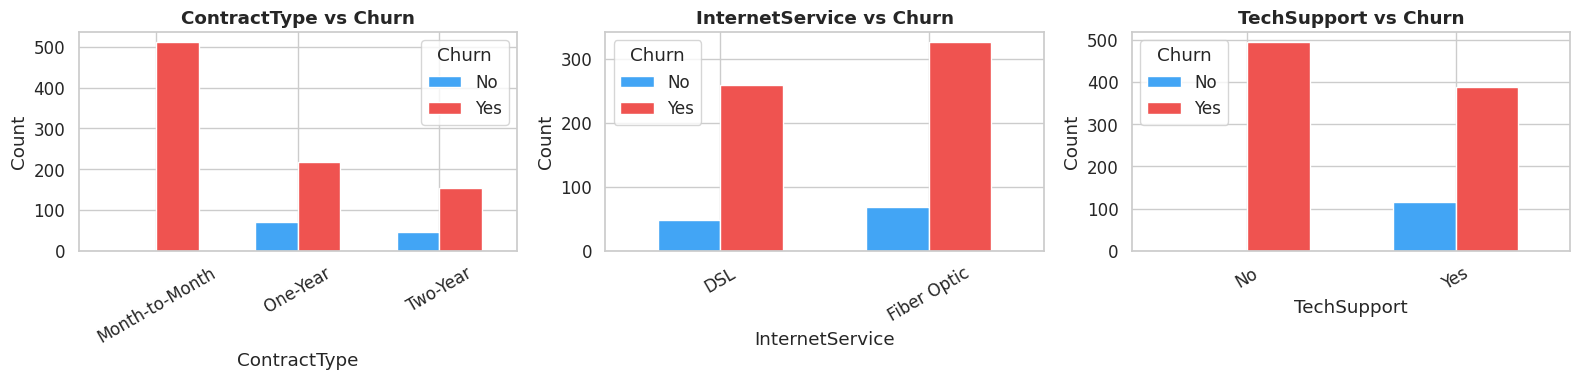

Figure saved: fig_cat_vs_churn.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cat_cols = ['ContractType', 'InternetService', 'TechSupport']
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Churn'])
    ct.plot.bar(ax=ax, color=['#42A5F5', '#EF5350'], edgecolor='white', width=0.6)
    ax.set_title(f'{col} vs Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.savefig('fig_cat_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_cat_vs_churn.png')

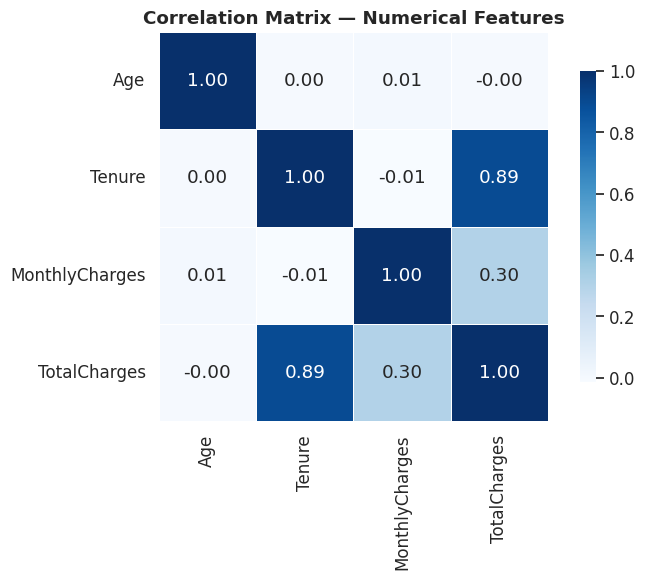

Figure saved: fig_correlation.png


In [12]:
num_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix  = df[num_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_correlation.png')

In [13]:
# --- Drop CustomerID ---
df_proc = df.drop(columns=['CustomerID']).copy()

# --- Impute missing InternetService with 'No Service' ---
df_proc['InternetService'] = df_proc['InternetService'].fillna('No Service')
print('Missing values after imputation:')
print(df_proc.isnull().sum())

Missing values after imputation:
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64


In [14]:
# --- Encode target (Churn: Yes=1, No=0) ---
le = LabelEncoder()
df_proc['Churn'] = le.fit_transform(df_proc['Churn'])  # Yes->1, No->0

# --- Binary label encode ---
df_proc['Gender']     = le.fit_transform(df_proc['Gender'])      # Male=1, Female=0
df_proc['TechSupport']= le.fit_transform(df_proc['TechSupport'])  # Yes=1, No=0

# --- One-hot encode multi-class categorical columns ---
df_proc = pd.get_dummies(df_proc, columns=['ContractType', 'InternetService'], drop_first=False)

print('Processed DataFrame shape:', df_proc.shape)
print('Columns:', list(df_proc.columns))
df_proc.head()

Processed DataFrame shape: (1000, 13)
Columns: ['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'TechSupport', 'Churn', 'ContractType_Month-to-Month', 'ContractType_One-Year', 'ContractType_Two-Year', 'InternetService_DSL', 'InternetService_Fiber Optic', 'InternetService_No Service']


,Age,Gender,Tenure,MonthlyCharges,TotalCharges,TechSupport,Churn,ContractType_Month-to-Month,ContractType_One-Year,ContractType_Two-Year,InternetService_DSL,InternetService_Fiber Optic,InternetService_No Service
0,49,1,4,88.35,353.40,1,1,True,False,False,False,True,False
1,43,1,0,36.67,0.00,1,1,True,False,False,False,True,False
2,51,0,2,63.79,127.58,0,1,True,False,False,False,True,False
3,60,0,8,102.34,818.72,1,1,False,True,False,True,False,False
4,42,1,32,69.01,2208.32,0,1,True,False,False,False,False,True


In [15]:
# --- Feature / Target split ---
X = df_proc.drop(columns=['Churn'])
y = df_proc['Churn']

# --- Train / Test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# --- Normalise numerical features ---
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
scaler   = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'Class balance (train): {dict(y_train.value_counts())}')

Training set  : 800 samples
Test set       : 200 samples
Class balance (train): {1: np.int64(706), 0: np.int64(94)}


After SMOTE — training samples: 1412
Class balance after SMOTE: {1: np.int64(706), 0: np.int64(706)}


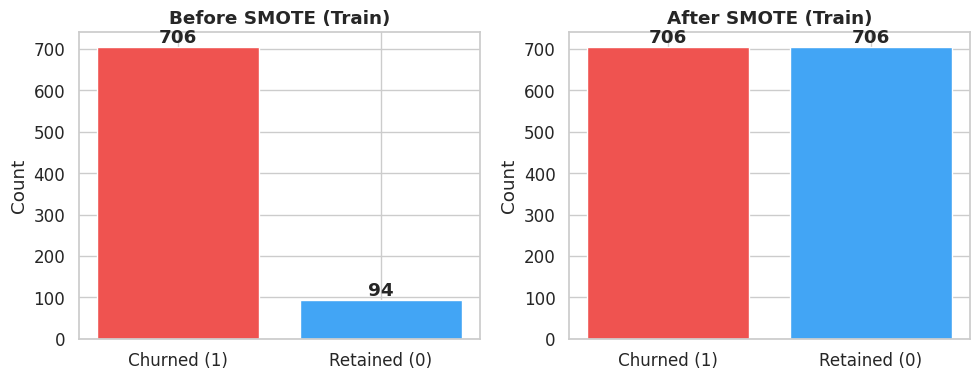

Figure saved: fig_smote.png


In [16]:
# --- SMOTE: oversample minority class in training data only ---
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE — training samples: {X_train_sm.shape[0]}')
print(f'Class balance after SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_sm).value_counts()],
    ['Before SMOTE (Train)', 'After SMOTE (Train)']
):
    ax.bar(['Churned (1)', 'Retained (0)'],
           [counts.get(1, 0), counts.get(0, 0)],
           color=['#EF5350', '#42A5F5'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_smote.png')

In [17]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=0.5),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                          activation='relu', solver='adam', random_state=42,
                                          early_stopping=True, validation_fraction=0.1)
}

# Train
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    print(f'  ✓ Trained: {name}')

  ✓ Trained: Logistic Regression
  ✓ Trained: Decision Tree
  ✓ Trained: Random Forest
  ✓ Trained: Neural Network (MLP)


In [18]:
results = []
preds   = {}
probs   = {}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    preds[name] = y_pred
    probs[name] = y_prob
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob) * 100, 2),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Performance Summary (%) ===')
results_df

=== Model Performance Summary (%) ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,94.0,100.0,93.22,96.49,98.80
Decision Tree,100.0,100.0,100.00,100.00,100.00
Random Forest,100.0,100.0,100.00,100.00,100.00
Neural Network (MLP),96.0,100.0,95.48,97.69,99.95


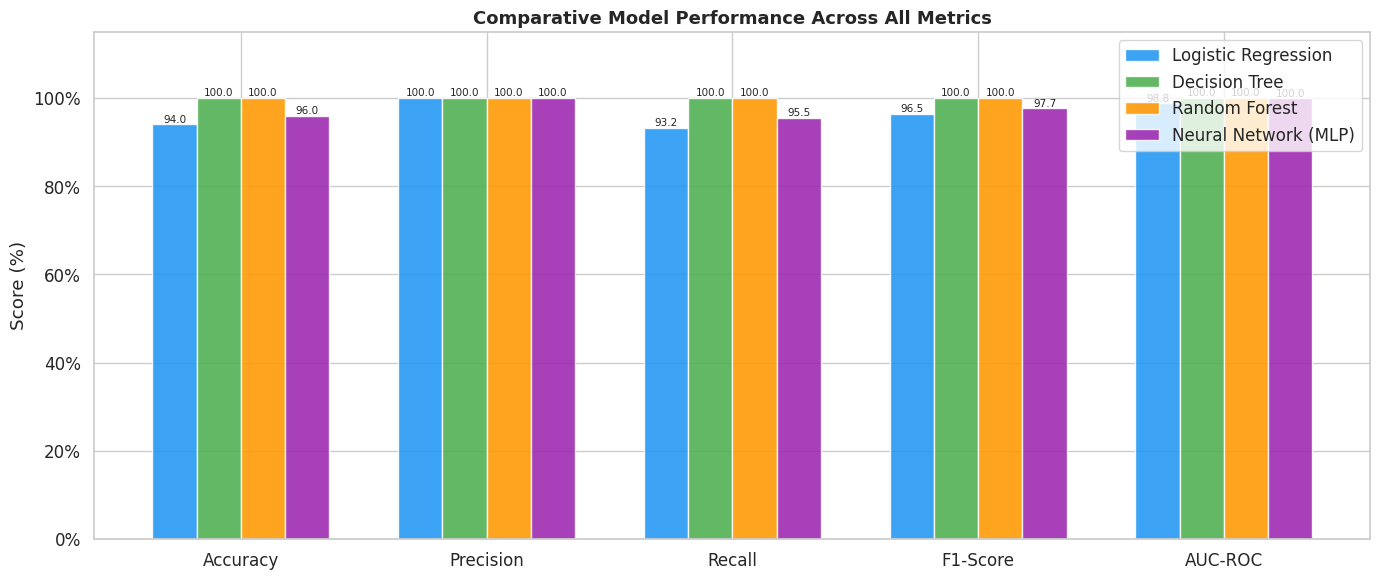

Figure saved: fig_model_comparison.png


In [ ]:
# --- Bar chart comparison ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x       = np.arange(len(metrics))
width   = 0.18
model_names = list(models.keys())

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, colour) in enumerate(zip(model_names, PALETTE)):
    vals = [results_df.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colour, alpha=0.88)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.1f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Comparative Model Performance Across All Metrics', fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_model_comparison.png')

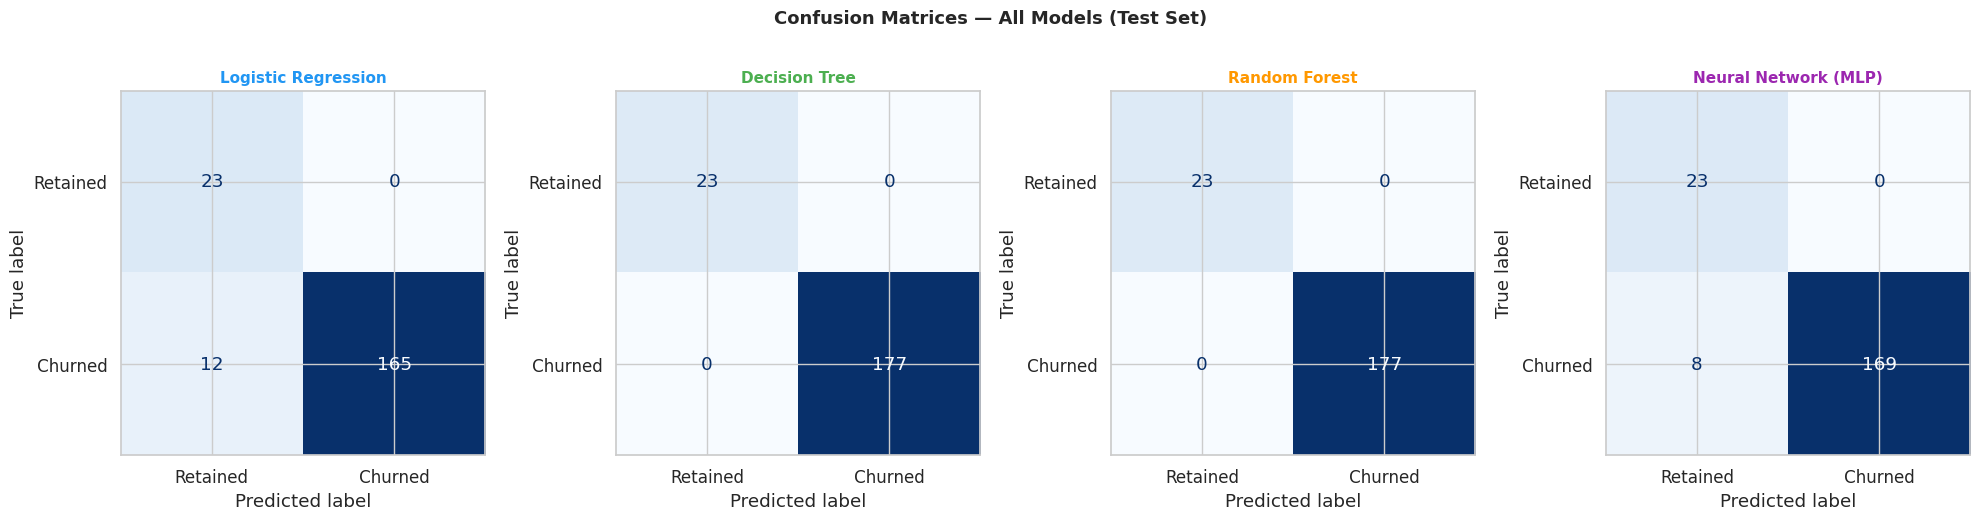

Figure saved: fig_confusion_matrices.png


In [25]:
model_names = list(models.keys())
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, colour) in zip(axes, zip(model_names, PALETTE)):
    cm = confusion_matrix(y_test, preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.title.set_color(colour)
plt.suptitle('Confusion Matrices — All Models (Test Set)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_confusion_matrices.png')

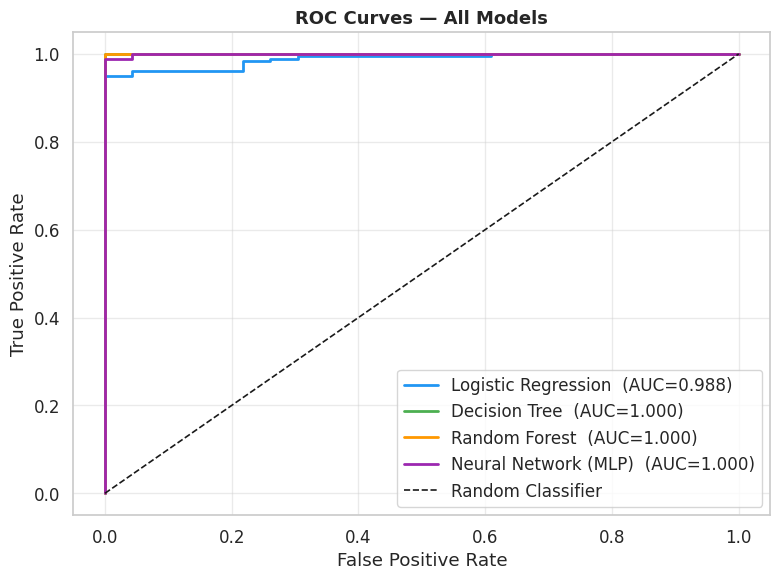

Figure saved: fig_roc_curves.png


In [26]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
for name, colour in zip(model_names, PALETTE):
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    auc = roc_auc_score(y_test, probs[name])
    ax.plot(fpr, tpr, lw=2, color=colour, label=f'{name}  (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_roc_curves.png')

In [27]:
# --- Detailed classification reports ---
for name in model_names:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds[name], target_names=['Retained (0)', 'Churned (1)']))


=== Logistic Regression ===
              precision    recall  f1-score   support

Retained (0)       0.66      1.00      0.79        23
 Churned (1)       1.00      0.93      0.96       177

    accuracy                           0.94       200
   macro avg       0.83      0.97      0.88       200
weighted avg       0.96      0.94      0.95       200


=== Decision Tree ===
              precision    recall  f1-score   support

Retained (0)       1.00      1.00      1.00        23
 Churned (1)       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


=== Random Forest ===
              precision    recall  f1-score   support

Retained (0)       1.00      1.00      1.00        23
 Churned (1)       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200

In [28]:
# --- 5-fold Cross-Validation (F1) ---
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation (F1-Score):')
for name, model in models.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f'  {name:30s}  Mean: {scores.mean()*100:.2f}%  ± {scores.std()*100:.2f}%')

5-Fold Cross-Validation (F1-Score):
  Logistic Regression             Mean: 94.80%  ± 1.25%
  Decision Tree                   Mean: 99.93%  ± 0.14%
  Random Forest                   Mean: 99.86%  ± 0.28%
  Neural Network (MLP)            Mean: 96.32%  ± 1.80%


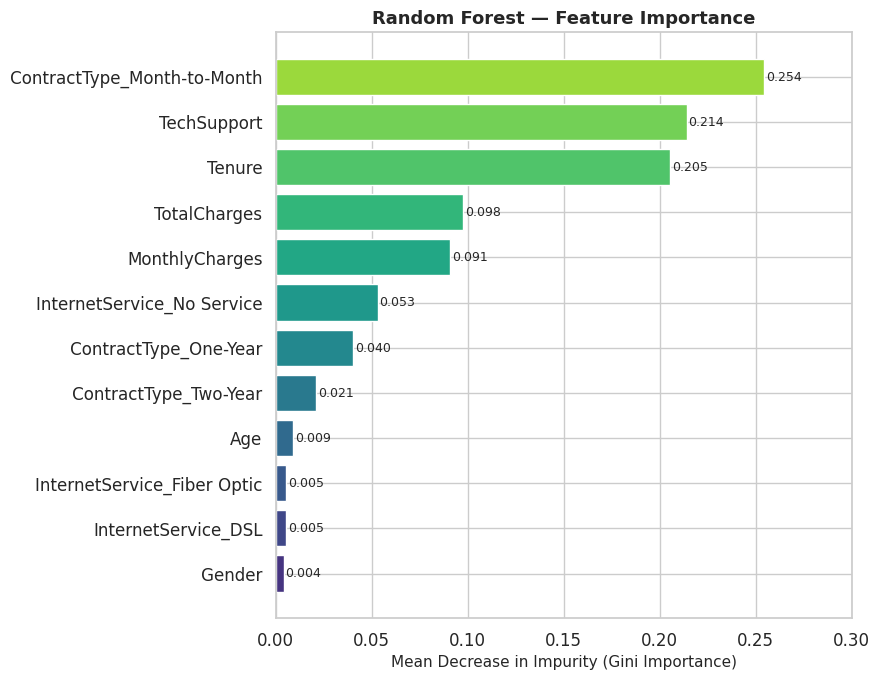

Figure saved: fig_feature_importance.png


In [29]:
# --- Random Forest Feature Importance ---
rf_model     = models['Random Forest']
importances  = rf_model.feature_importances_
feat_names   = X_train.columns

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=plt.cm.viridis(np.linspace(0.15, 0.85, len(feat_df))), edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontsize=11)
ax.set_title('Random Forest — Feature Importance', fontweight='bold', fontsize=13)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.set_xlim(0, feat_df['Importance'].max() * 1.18)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_feature_importance.png')

In [30]:
# --- SHAP Values (Random Forest) ---
print('Computing SHAP values (TreeExplainer — Random Forest)...')
explainer    = shap.TreeExplainer(rf_model)
shap_values  = explainer.shap_values(X_test)

# Handle different SHAP output shapes:
#   list of 2 arrays -> [class0, class1]
#   3D array (n, features, classes) -> slice class 1
#   2D array (n, features) -> already class 1
if isinstance(shap_values, list):
    sv = shap_values[1]          # list format
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]    # 3D format (n, features, 2)
else:
    sv = shap_values              # already 2D

print('SHAP values computed. Shape:', sv.shape)

Computing SHAP values (TreeExplainer — Random Forest)...
SHAP values computed. Shape: (200, 12)


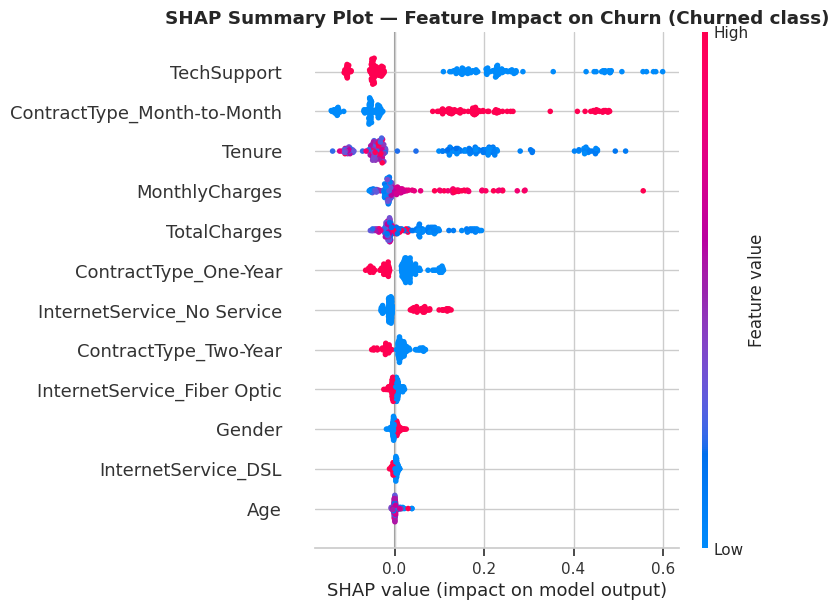

Figure saved: fig_shap_summary.png


In [31]:
# --- SHAP Summary (Beeswarm) ---
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, plot_type='dot', show=False,
                  feature_names=list(feat_names), max_display=12)
plt.title('SHAP Summary Plot — Feature Impact on Churn (Churned class)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_shap_summary.png')

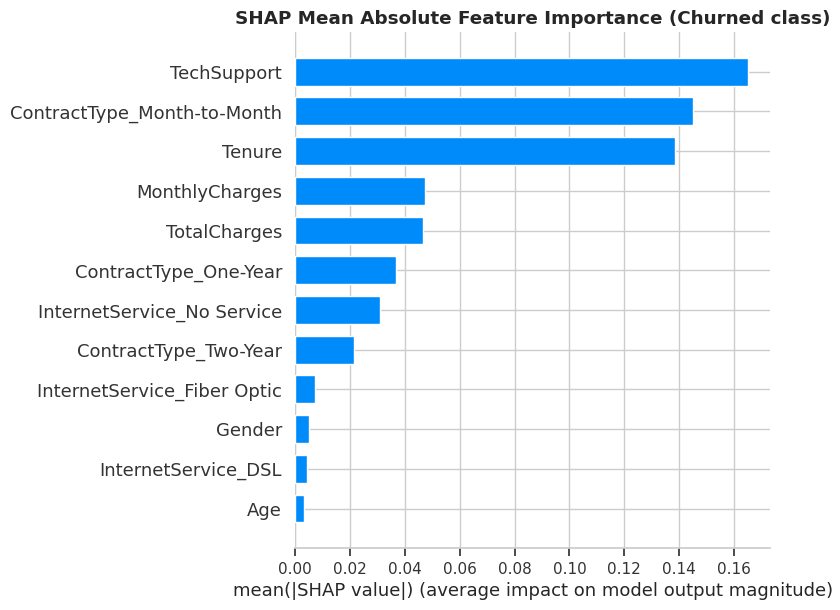

Figure saved: fig_shap_bar.png


In [32]:
# --- SHAP Bar (mean absolute) ---
plt.figure(figsize=(9, 5))
shap.summary_plot(sv, X_test, plot_type='bar', show=False,
                  feature_names=list(feat_names), max_display=12)
plt.title('SHAP Mean Absolute Feature Importance (Churned class)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_shap_bar.png')

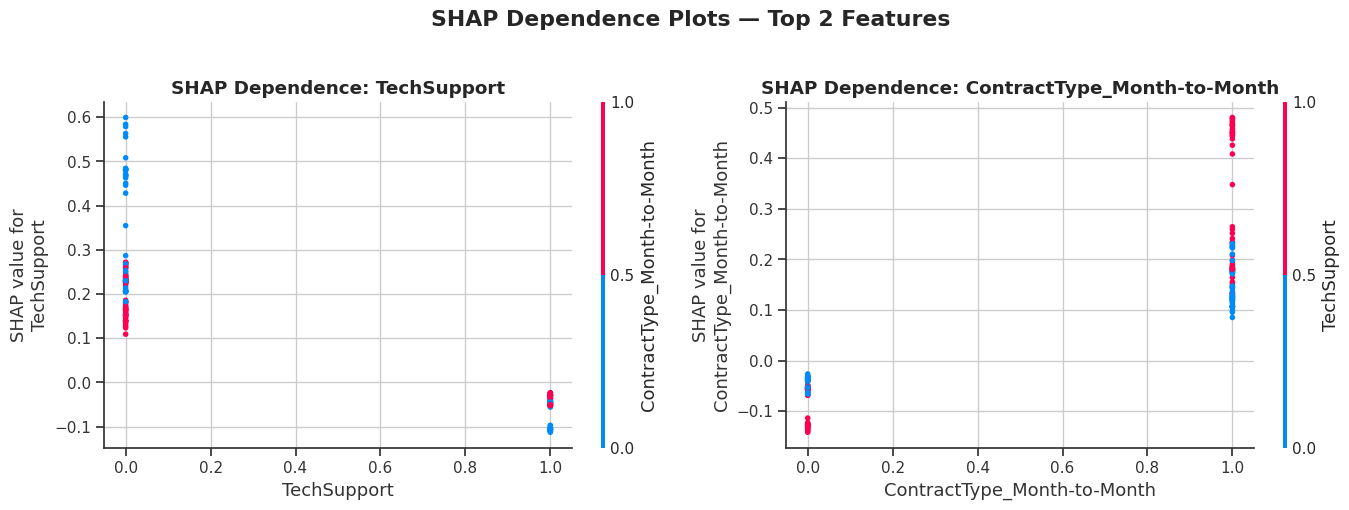

Figure saved: fig_shap_dependence.png


In [33]:
# --- SHAP Dependence Plots (top 2 features by SHAP mean abs) ---
shap_means = np.abs(sv).mean(axis=0)
top2_idx   = np.argsort(shap_means)[::-1][:2]
top2_feats = [list(feat_names)[int(i)] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_feats):
    shap.dependence_plot(feat, sv, X_test, ax=ax, show=False,
                         feature_names=list(feat_names))
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')
plt.suptitle('SHAP Dependence Plots — Top 2 Features', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_shap_dependence.png')

In [34]:
print('======================================')
print('      FINAL PERFORMANCE SUMMARY       ')
print('======================================')
print(results_df.to_string())
print()

best_f1  = results_df['F1-Score'].idxmax()
best_auc = results_df['AUC-ROC'].idxmax()
print(f'Best model by F1-Score  : {best_f1}  ({results_df.loc[best_f1, "F1-Score"]}%)')
print(f'Best model by AUC-ROC   : {best_auc}  ({results_df.loc[best_auc, "AUC-ROC"]}%)')

      FINAL PERFORMANCE SUMMARY       
                      Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                               
Logistic Regression       94.0      100.0   93.22     96.49    98.80
Decision Tree            100.0      100.0  100.00    100.00   100.00
Random Forest            100.0      100.0  100.00    100.00   100.00
Neural Network (MLP)      96.0      100.0   95.48     97.69    99.95

Best model by F1-Score  : Decision Tree  (100.0%)
Best model by AUC-ROC   : Decision Tree  (100.0%)


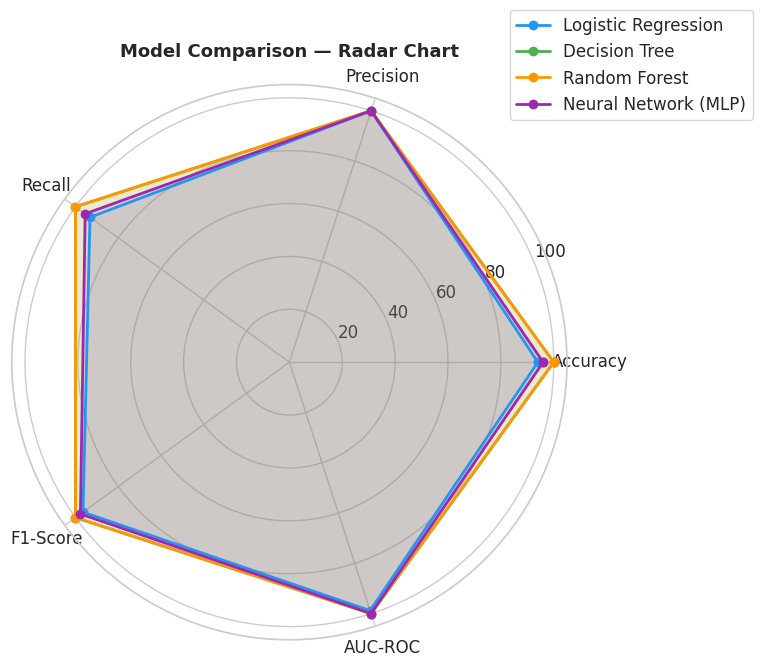

Figure saved: fig_radar.png


In [35]:
# --- Radar / Spider Chart Comparison ---
from matplotlib.patches import FancyArrowPatch

metrics_r = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
n = len(metrics_r)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name, colour in zip(model_names, PALETTE):
    vals = [results_df.loc[name, m] for m in metrics_r]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=colour, label=name)
    ax.fill(angles, vals, alpha=0.12, color=colour)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_r, fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('Model Comparison — Radar Chart', fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('fig_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_radar.png')

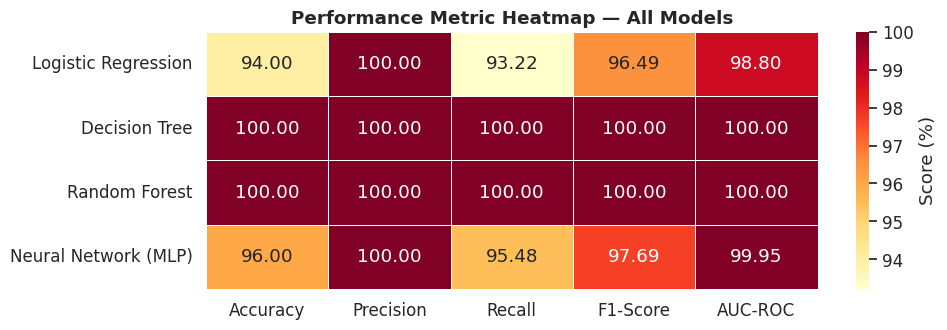

Figure saved: fig_heatmap_results.png


In [36]:
# --- Heat-map style results table ---
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(results_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Score (%)'})
ax.set_title('Performance Metric Heatmap — All Models', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_heatmap_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_heatmap_results.png')